
# Projekt: dyfuzja ciepła w ścianie domu — czy izolacja naprawdę działa?

**Temat:** numeryczna symulacja przepływu ciepła przez ścianę budynku oraz analiza skuteczności materiałów izolacyjnych.

Pomysł jest prosty i praktyczny: mamy dom ogrzewany od środka, zimne powietrze na zewnątrz i ścianę złożoną z warstw, np. tynk + cegła + styropian. Chcemy policzyć, jak temperatura rozkłada się w ścianie i ile ciepła ucieka z domu.

Notebook pokazuje:

- model fizyczny i założenia,
- jawną metodę Eulera,
- niejawną metodę Eulera,
- metodę Cranka–Nicolsona,
- warunek stabilności i przykład tego, co idzie źle po jego złamaniu,
- porównanie ściany ocieplonej i nieocieplonej,
- analizę dokładności na przykładzie z rozwiązaniem analitycznym,
- pomiar czasu działania metod,
- szkic pakietu w Julii gotowego do wrzucenia na GitHuba.



## 1. Model matematyczny

Dla jednowymiarowej ściany rozważamy równanie przewodnictwa ciepła z materiałami zależnymi od położenia:

$$
\rho(x)c(x)\frac{\partial T}{\partial t}
=
\frac{\partial}{\partial x}\left(k(x)\frac{\partial T}{\partial x}\right),
$$

gdzie:

- $T(x,t)$ — temperatura w ścianie,
- $k(x)$ — przewodność cieplna materiału $[W/(mK)]$,
- $\rho(x)$ — gęstość $[kg/m^3]$,
- $c(x)$ — ciepło właściwe $[J/(kgK)]$.

Dla jednorodnego materiału równanie redukuje się do klasycznej postaci:

$$
\frac{\partial T}{\partial t}=\alpha \frac{\partial^2 T}{\partial x^2},
\qquad
\alpha=\frac{k}{\rho c}.
$$

W projekcie przyjmujemy warunki brzegowe Dirichleta:

$$
T(0,t)=T_{wew}, \qquad T(L,t)=T_{zew}(t).
$$

Interpretacja:

- lewa strona ściany jest od strony ogrzewanego pokoju,
- prawa strona ściany jest od strony zewnętrznej.


## Skąd bierze się równanie przewodzenia ciepła w ścianie?

Modelujemy przepływ ciepła przez ścianę budynku. Temperatura zależy od położenia i czasu:

$$
T = T(x,t)
$$

Dla ściany wielowarstwowej parametry materiałowe zależą od położenia:

$$
k = k(x), \qquad \rho = \rho(x), \qquad c = c(x)
$$

gdzie:

- $ k(x)\ $ — współczynnik przewodzenia ciepła,
- $\rho(x)$ — gęstość materiału,
- $ c(x)\ $ — ciepło właściwe.

### Prawo Fouriera

Strumień ciepła opisuje wzór:

$$
q(x,t) = -k(x)\frac{\partial T}{\partial x}
$$

Minus oznacza, że ciepło płynie od temperatury wyższej do niższej.

### Bilans energii

Zmiana energii w małym fragmencie ściany wynika z różnicy między ciepłem wpływającym i wypływającym:

$$
\rho(x)c(x)\frac{\partial T}{\partial t}
=
-\frac{\partial q}{\partial x}
$$

Podstawiamy prawo Fouriera:

$$
q(x,t) = -k(x)\frac{\partial T}{\partial x}
$$

Dostajemy:

$$
\rho(x)c(x)\frac{\partial T}{\partial t}
=
\frac{\partial}{\partial x}
\left(
k(x)\frac{\partial T}{\partial x}
\right)
$$

To jest równanie przewodzenia ciepła dla ściany niejednorodnej.

### Przypadek jednorodny

Jeżeli materiał jest jednorodny, to $ k $, $\rho$ i $ c $ są stałe. Wtedy:

$$
\rho c \frac{\partial T}{\partial t}
=
k \frac{\partial^2 T}{\partial x^2}
$$

Po podzieleniu przez $\rho$ :

$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial x^2}
$$

gdzie:

$$
\alpha = \frac{k}{\rho c}
$$

Parametr $\alpha$ to dyfuzyjność cieplna materiału.


## 2. Instalacja i import pakietów

Ten notebook używa głównie standardowych bibliotek Julii. Do wykresów używany jest `Plots.jl`.


In [1]:

using LinearAlgebra
using SparseArrays
using Statistics
using Printf

try
    using Plots
catch
    import Pkg
    Pkg.add("Plots")
    using Plots
end

default(size=(900, 520), linewidth=2)



## 3. Dane materiałowe

Wartości poniżej są orientacyjne i służą do projektu numerycznego. Dla pracy końcowej można je zastąpić wartościami z norm, podręczników lub kart materiałowych producentów.


In [2]:

Base.@kwdef struct Layer
    name::String
    thickness::Float64   # m
    k::Float64           # W/(m K)
    rho::Float64         # kg/m^3
    c::Float64           # J/(kg K)
end

function print_layers(layers)
    println("Warstwy ściany:")
    for l in layers
        @printf("%-24s grubość = %.3f m, k = %.3f W/(mK), rho*c = %.2e J/(m³K)\n",
                l.name, l.thickness, l.k, l.rho*l.c)
    end
    R = sum(l.thickness / l.k for l in layers)
    @printf("\nOpór cieplny R = %.3f m²K/W\n", R)
    @printf("Współczynnik U = %.3f W/(m²K)\n", 1/R)
end

# ściana bez ocieplenia
wall_no_insulation = [
    Layer(name="tynk wewnętrzny", thickness=0.015, k=0.70, rho=1800.0, c=840.0),
    Layer(name="cegła pełna",       thickness=0.240, k=0.77, rho=1800.0, c=840.0),
    Layer(name="tynk zewnętrzny",  thickness=0.015, k=0.70, rho=1800.0, c=840.0)
]

# ściana z izolacją
wall_with_insulation = [
    Layer(name="tynk wewnętrzny", thickness=0.015, k=0.70,  rho=1800.0, c=840.0),
    Layer(name="cegła pełna",       thickness=0.240, k=0.77,  rho=1800.0, c=840.0),
    Layer(name="styropian EPS",     thickness=0.150, k=0.036, rho=20.0,   c=1450.0),
    Layer(name="tynk zewnętrzny",  thickness=0.015, k=0.70,  rho=1800.0, c=840.0)
]

print_layers(wall_with_insulation)


Warstwy ściany:
tynk wewnętrzny          grubość = 0.015 m, k = 0.700 W/(mK), rho*c = 1.51e+06 J/(m³K)
cegła pełna              grubość = 0.240 m, k = 0.770 W/(mK), rho*c = 1.51e+06 J/(m³K)
styropian EPS            grubość = 0.150 m, k = 0.036 W/(mK), rho*c = 2.90e+04 J/(m³K)
tynk zewnętrzny          grubość = 0.015 m, k = 0.700 W/(mK), rho*c = 1.51e+06 J/(m³K)

Opór cieplny R = 4.521 m²K/W
Współczynnik U = 0.221 W/(m²K)



## 4. Budowa siatki obliczeniowej

Poniższy wykres przedstawia rozkład współczynnika przewodzenia ciepła \(k(x)\) w analizowanej ścianie wielowarstwowej.

Ściana składa się z czterech warstw: tynku wewnętrznego, cegły, styropianu oraz tynku zewnętrznego. Każdy materiał charakteryzuje się inną przewodnością cieplną, dlatego funkcja \(k(x)\) jest nieciągła i zmienia się na granicach warstw.

Szczególną uwagę zwraca warstwa styropianu, której przewodność cieplna wynosi około \(0.036\;W/(mK)\), podczas gdy dla cegły jest to około \(0.77\;W/(mK)\). Oznacza to, że styropian przewodzi ciepło ponad 20 razy gorzej od cegły, dzięki czemu skutecznie ogranicza straty energii i pełni funkcję izolacji termicznej.

Wykres ten przedstawia parametry materiałowe wykorzystane w modelu i stanowi dane wejściowe do równania przewodzenia ciepła.


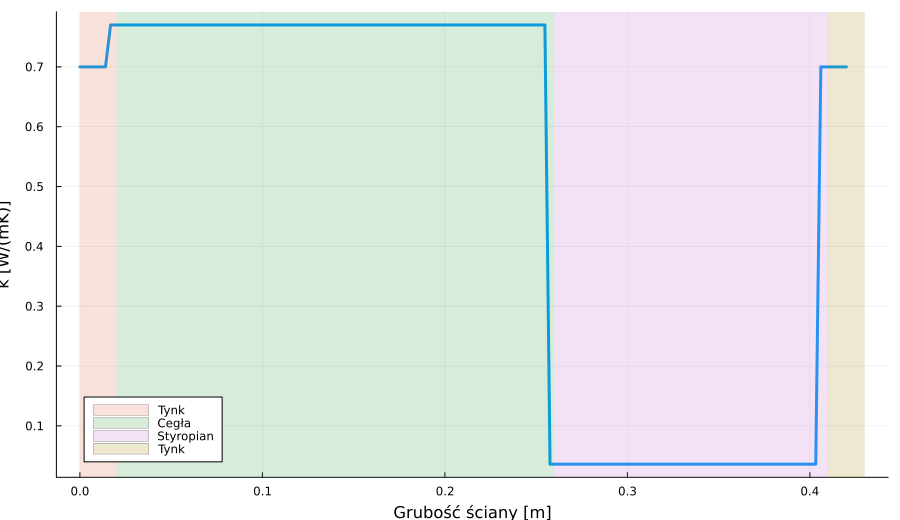

In [17]:

function build_wall(layers::Vector{Layer}; Nx::Int=151)
    L = sum(l.thickness for l in layers)
    x = collect(range(0.0, L; length=Nx))
    edges = cumsum([l.thickness for l in layers])

    k = zeros(Float64, Nx)
    rhoc = zeros(Float64, Nx)
    names = Vector{String}(undef, Nx)

    for (i, xi) in enumerate(x)
        # +eps pomaga poprawnie przypisać punkt x=0 do pierwszej warstwy
        j = searchsortedfirst(edges, xi + eps(Float64))
        j = clamp(j, 1, length(layers))
        layer = layers[j]
        k[i] = layer.k
        rhoc[i] = layer.rho * layer.c
        names[i] = layer.name
    end

    return x, k, rhoc, names
end

x, k, rhoc, names = build_wall(wall_with_insulation; Nx=151)


p = plot(x, k,
    lw=3,
    xlabel="Grubość ściany [m]",
    ylabel="k [W/(mK)]",
    label=""
)

vspan!([0.0,0.02], alpha=0.2, label="Tynk")
vspan!([0.02,0.26], alpha=0.2, label="Cegła")
vspan!([0.26,0.41], alpha=0.2, label="Styropian")
vspan!([0.41,0.43], alpha=0.2, label="Tynk")



## 5. Dyskretyzacja operatora przewodzenia

Dla materiałów zmiennych w przestrzeni wygodna jest postać konserwatywna:

$$
\rho_i c_i \frac{dT_i}{dt}
= \frac{1}{\Delta x^2}
\left[
 k_{i+1/2}(T_{i+1}-T_i)-k_{i-1/2}(T_i-T_{i-1})
\right].
$$

Na granicach między materiałami używamy średniej harmonicznej:

$$
k_{i+1/2}=\frac{2k_i k_{i+1}}{k_i+k_{i+1}}.
$$

Jest to sensowniejsze niż zwykła średnia arytmetyczna, bo na styku materiałów ograniczeniem jest warstwa o mniejszej przewodności.


In [4]:

harmonic_mean(a, b) = 2a*b/(a+b)

function face_conductivity(k)
    return [harmonic_mean(k[i], k[i+1]) for i in 1:length(k)-1]
end

function build_operator(k, rhoc, dx)
    N = length(k)
    n = N - 2                       # liczba niewiadomych bez brzegów
    kh = face_conductivity(k)

    rows = Int[]
    cols = Int[]
    vals = Float64[]

    leftcoef = zeros(Float64, n)    # wkład lewego warunku brzegowego
    rightcoef = zeros(Float64, n)   # wkład prawego warunku brzegowego

    for j in 1:n
        i = j + 1                   # indeks globalny w pełnej siatce
        aL = kh[i-1] / (rhoc[i] * dx^2)
        aR = kh[i]   / (rhoc[i] * dx^2)

        # przekątna
        push!(rows, j); push!(cols, j); push!(vals, -(aL + aR))

        # sąsiad z lewej lub brzeg
        if j > 1
            push!(rows, j); push!(cols, j-1); push!(vals, aL)
        else
            leftcoef[j] = aL
        end

        # sąsiad z prawej lub brzeg
        if j < n
            push!(rows, j); push!(cols, j+1); push!(vals, aR)
        else
            rightcoef[j] = aR
        end
    end

    L = sparse(rows, cols, vals, n, n)
    return L, leftcoef, rightcoef
end

function boundary_vector(leftcoef, rightcoef, Tleft, Tright)
    return leftcoef .* Tleft .+ rightcoef .* Tright
end

dx = x[2] - x[1]
Lop, leftcoef, rightcoef = build_operator(k, rhoc, dx)
size(Lop)


(149, 149)


## 6. Metody numeryczne

### 6.1 Jawna metoda Eulera

Schemat:

$$
T^{n+1}=T^n+\Delta t\,L T^n.
$$

Zaleta: bardzo prosty i tani krok czasowy.

Wada: metoda jest stabilna tylko dla odpowiednio małego kroku czasu.

### 6.2 Niejawna metoda Eulera

Schemat:

$$
(I-\Delta t L)T^{n+1}=T^n.
$$

Zaleta: stabilna dla dużych kroków czasu.

Wada: w każdym kroku rozwiązujemy układ równań liniowych.

### 6.3 Crank–Nicolson

Schemat:

$$
(I-\frac{\Delta t}{2}L)T^{n+1}=(I+\frac{\Delta t}{2}L)T^n.
$$

Zaleta: dokładniejszy w czasie niż obie metody Eulera.


In [5]:

function explicit_dt_limit(k, rhoc, dx; safety=0.45)
    kh = face_conductivity(k)
    rates = [(kh[i-1] + kh[i]) / (rhoc[i] * dx^2) for i in 2:length(k)-1]
    return safety / maximum(rates)
end

function solve_wall_explicit(x, k, rhoc;
                             T_initial,
                             T_left = t -> 20.0,
                             T_right = t -> -10.0,
                             dt,
                             t_end,
                             save_every=1)
    dx = x[2] - x[1]
    Lop, leftcoef, rightcoef = build_operator(k, rhoc, dx)

    T = copy(T_initial)
    T[1] = T_left(0.0)
    T[end] = T_right(0.0)

    nt = ceil(Int, t_end/dt)
    times = Float64[]
    saved = Vector{Vector{Float64}}()

    for n in 0:nt
        t = n * dt
        if n % save_every == 0
            push!(times, t)
            push!(saved, copy(T))
        end
        n == nt && break

        b = boundary_vector(leftcoef, rightcoef, T_left(t), T_right(t))
        T[2:end-1] .= T[2:end-1] .+ dt .* (Lop * T[2:end-1] .+ b)
        T[1] = T_left(t + dt)
        T[end] = T_right(t + dt)
    end

    return times, permutedims(hcat(saved...))
end

function solve_wall_theta(x, k, rhoc;
                          T_initial,
                          T_left = t -> 20.0,
                          T_right = t -> -10.0,
                          dt,
                          t_end,
                          theta=1.0,
                          save_every=1)
    dx = x[2] - x[1]
    Lop, leftcoef, rightcoef = build_operator(k, rhoc, dx)
    n_unknowns = length(x) - 2
    Id = spdiagm(0 => ones(n_unknowns))

    A = Id - theta * dt * Lop
    B = Id + (1 - theta) * dt * Lop
    F = factorize(A)

    T = copy(T_initial)
    T[1] = T_left(0.0)
    T[end] = T_right(0.0)

    nt = ceil(Int, t_end/dt)
    times = Float64[]
    saved = Vector{Vector{Float64}}()

    for n in 0:nt
        t = n * dt
        if n % save_every == 0
            push!(times, t)
            push!(saved, copy(T))
        end
        n == nt && break

        b_now = boundary_vector(leftcoef, rightcoef, T_left(t), T_right(t))
        b_next = boundary_vector(leftcoef, rightcoef, T_left(t + dt), T_right(t + dt))

        rhs = B * T[2:end-1] .+ dt .* ((1 - theta) .* b_now .+ theta .* b_next)
        T[2:end-1] .= F \ rhs
        T[1] = T_left(t + dt)
        T[end] = T_right(t + dt)
    end

    return times, permutedims(hcat(saved...))
end

solve_wall_implicit(args...; kwargs...) = solve_wall_theta(args...; theta=1.0, kwargs...)
solve_wall_crank_nicolson(args...; kwargs...) = solve_wall_theta(args...; theta=0.5, kwargs...)


solve_wall_crank_nicolson (generic function with 1 method)


## 7. Eksperyment 1 — zimna noc i ogrzewany dom

Zakładamy:

- temperatura wewnątrz: $20^\circ C$,
- temperatura zewnętrzna: $-10^\circ C$,
- początkowo cała ściana ma $0^\circ C$,
- symulujemy 48 godzin.

Pytanie: jak szybko ściana zbliża się do stanu ustalonego?


In [6]:

Tin = 20.0
Tout = -10.0
T_left(t) = Tin
T_right(t) = Tout

t_end = 48 * 3600.0   # 48 h

x, k, rhoc, names = build_wall(wall_with_insulation; Nx=151)
T0 = fill(0.0, length(x))
T0[1] = Tin
T0[end] = Tout

dx = x[2] - x[1]
dt_max = explicit_dt_limit(k, rhoc, dx)
dt = 0.8 * dt_max
save_every = max(1, round(Int, 3600 / dt))   # zapis mniej więcej co godzinę

@printf("dx = %.5f m\n", dx)
@printf("stabilny dt dla metody jawnej ≈ %.2f s\n", dt_max)
@printf("użyty dt = %.2f s\n", dt)
@printf("save_every = %d kroków\n", save_every)

times_exp, sol_exp = solve_wall_explicit(x, k, rhoc;
    T_initial=T0,
    T_left=T_left,
    T_right=T_right,
    dt=dt,
    t_end=t_end,
    save_every=save_every
)

println("Liczba zapisanych profili: ", length(times_exp))


dx = 0.00280 m
stabilny dt dla metody jawnej ≈ 0.98 s
użyty dt = 0.78 s
save_every = 4609 kroków
Liczba zapisanych profili: 48


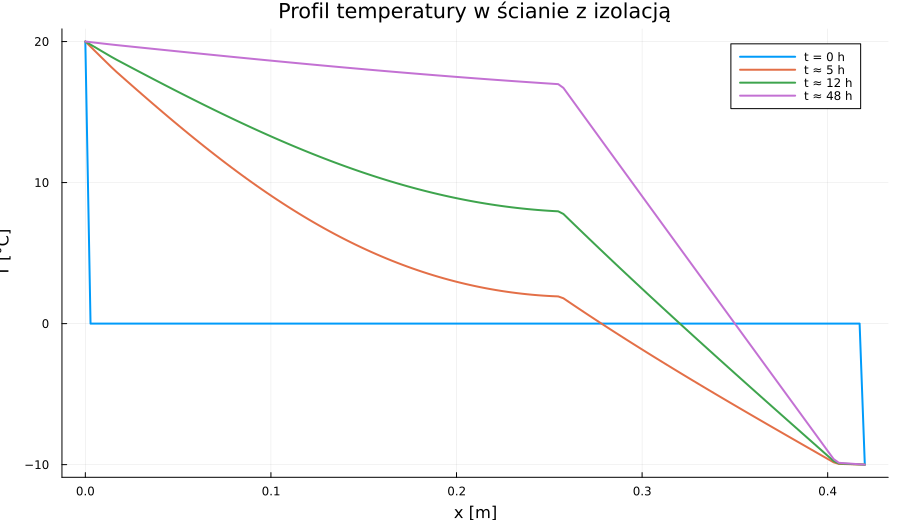

In [7]:

plot(x, sol_exp[1, :], label="t = 0 h")
plot!(x, sol_exp[6, :], label="t ≈ 5 h")
plot!(x, sol_exp[13, :], label="t ≈ 12 h")
plot!(x, sol_exp[end, :], label="t ≈ 48 h")
plot!(xlabel="x [m]", ylabel="T [°C]",
      title="Profil temperatury w ścianie z izolacją")


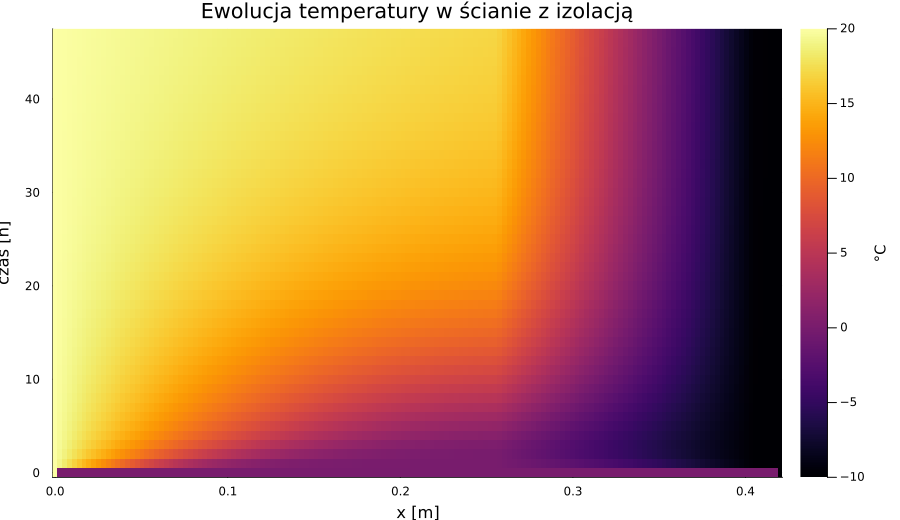

In [8]:

heatmap(x, times_exp ./ 3600, sol_exp,
        xlabel="x [m]",
        ylabel="czas [h]",
        title="Ewolucja temperatury w ścianie z izolacją",
        colorbar_title="°C")



## 8. Eksperyment 2 — co idzie źle po złamaniu warunku stabilności?

Dla jawnej metody Eulera krok czasowy nie może być zbyt duży. Gdy wybierzemy $\Delta t$ kilka razy większe od dopuszczalnego, rozwiązanie może zacząć oscylować i eksplodować numerycznie.

To jest bardzo dobra demonstracja w prezentacji: fizycznie temperatura powinna być między temperaturą wewnętrzną i zewnętrzną, a numerycznie pojawiają się absurdalne wartości.


zły krok dt_bad = 2.93 s, czyli 3.0 × dt_max


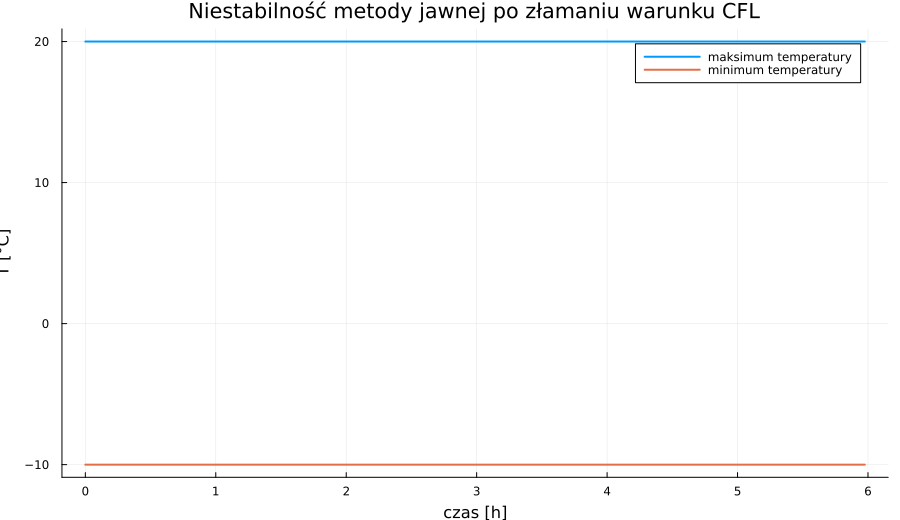

In [9]:

dt_bad = 3.0 * dt_max
save_every_bad = max(1, round(Int, 300 / dt_bad))  # zapis co około 5 minut

@printf("zły krok dt_bad = %.2f s, czyli %.1f × dt_max\n", dt_bad, dt_bad/dt_max)

times_bad, sol_bad = solve_wall_explicit(x, k, rhoc;
    T_initial=T0,
    T_left=T_left,
    T_right=T_right,
    dt=dt_bad,
    t_end=6 * 3600.0,
    save_every=save_every_bad
)

maxT = vec(maximum(sol_bad, dims=2))
minT = vec(minimum(sol_bad, dims=2))

plot(times_bad ./ 3600, maxT, label="maksimum temperatury")
plot!(times_bad ./ 3600, minT, label="minimum temperatury")
plot!(xlabel="czas [h]", ylabel="T [°C]",
      title="Niestabilność metody jawnej po złamaniu warunku CFL")



## 9. Eksperyment 3 — metoda niejawna i Crank–Nicolson

Metody niejawne pozwalają użyć dużo większego kroku czasowego. To szczególnie ważne przy symulacjach długich okresów, np. kilku dni.


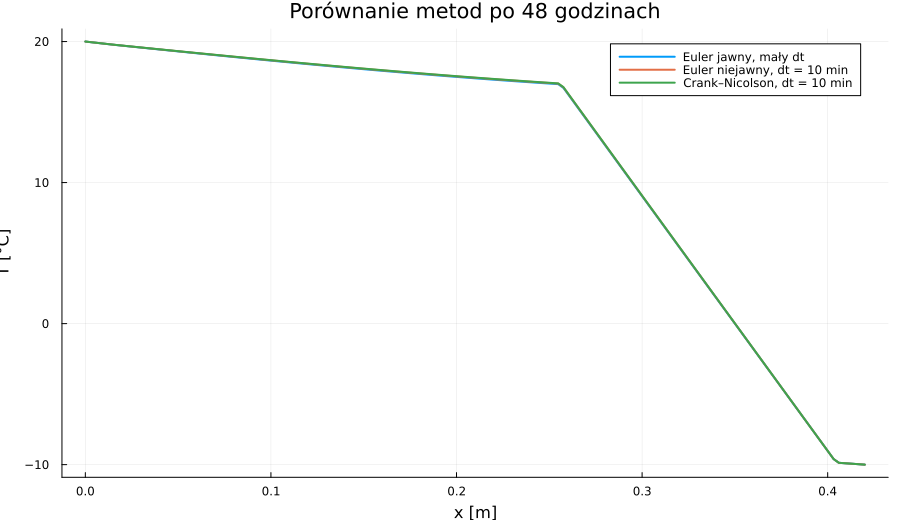

In [10]:

dt_big = 10 * 60.0      # 10 minut
save_every_big = 1

times_be, sol_be = solve_wall_implicit(x, k, rhoc;
    T_initial=T0,
    T_left=T_left,
    T_right=T_right,
    dt=dt_big,
    t_end=t_end,
    save_every=save_every_big
)

times_cn, sol_cn = solve_wall_crank_nicolson(x, k, rhoc;
    T_initial=T0,
    T_left=T_left,
    T_right=T_right,
    dt=dt_big,
    t_end=t_end,
    save_every=save_every_big
)

plot(x, sol_exp[end, :], label="Euler jawny, mały dt")
plot!(x, sol_be[end, :], label="Euler niejawny, dt = 10 min")
plot!(x, sol_cn[end, :], label="Crank–Nicolson, dt = 10 min")
plot!(xlabel="x [m]", ylabel="T [°C]",
      title="Porównanie metod po 48 godzinach")



## 10. Eksperyment 4 — ściana ocieplona kontra nieocieplona

Teraz porównujemy straty ciepła. Dla profilu temperatury liczymy strumień ciepła:

$$
q = -k \frac{\partial T}{\partial x}.
$$

Wynik ma jednostkę $W/m^2$, czyli mówi, ile watów ucieka przez każdy metr kwadratowy ściany.


Ściana bez ocieplenia: q_num = 98.27 W/m², q_teoria = 84.62 W/m²
Ściana z ociepleniem:  q_num = 10.28 W/m², q_teoria = 6.64 W/m²
Redukcja strat ≈ 89.5 %


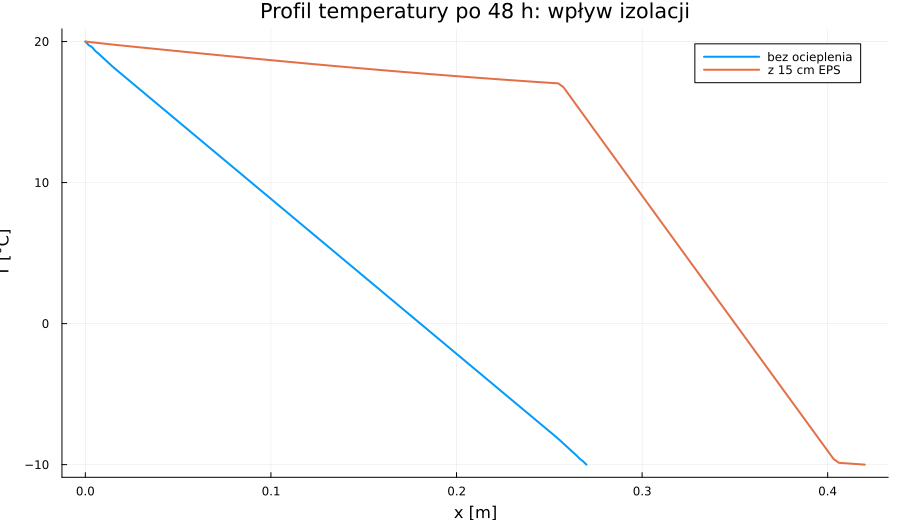

In [11]:

function heat_flux_left(T, k, dx)
    kh = face_conductivity(k)
    return -kh[1] * (T[2] - T[1]) / dx
end

function steady_flux_from_layers(layers, Tin, Tout)
    R = sum(l.thickness / l.k for l in layers)
    return (Tin - Tout) / R
end

function simulate_final_profile(layers; Nx=151, dt_minutes=10, hours=48)
    x, k, rhoc, names = build_wall(layers; Nx=Nx)
    T0 = fill(0.0, length(x))
    T0[1] = Tin
    T0[end] = Tout
    times, sol = solve_wall_crank_nicolson(x, k, rhoc;
        T_initial=T0,
        T_left=T_left,
        T_right=T_right,
        dt=dt_minutes*60.0,
        t_end=hours*3600.0,
        save_every=1
    )
    dx = x[2] - x[1]
    q_num = heat_flux_left(sol[end, :], k, dx)
    q_steady = steady_flux_from_layers(layers, Tin, Tout)
    return x, sol[end, :], q_num, q_steady
end

x_no, T_no, q_no, q_no_steady = simulate_final_profile(wall_no_insulation; Nx=151)
x_in, T_in, q_in, q_in_steady = simulate_final_profile(wall_with_insulation; Nx=151)

@printf("Ściana bez ocieplenia: q_num = %.2f W/m², q_teoria = %.2f W/m²\n", q_no, q_no_steady)
@printf("Ściana z ociepleniem:  q_num = %.2f W/m², q_teoria = %.2f W/m²\n", q_in, q_in_steady)
@printf("Redukcja strat ≈ %.1f %%\n", 100 * (1 - q_in/q_no))

plot(x_no, T_no, label="bez ocieplenia")
plot!(x_in, T_in, label="z 15 cm EPS")
plot!(xlabel="x [m]", ylabel="T [°C]",
      title="Profil temperatury po 48 h: wpływ izolacji")


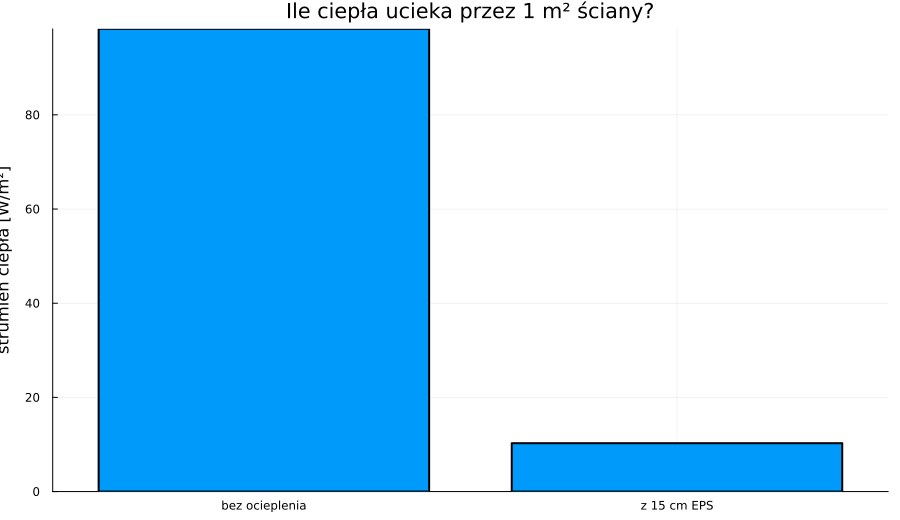

In [12]:

labels = ["bez ocieplenia", "z 15 cm EPS"]
fluxes = [q_no, q_in]
bar(labels, fluxes,
    ylabel="strumień ciepła [W/m²]",
    title="Ile ciepła ucieka przez 1 m² ściany?",
    legend=false)



## 11. Eksperyment 5 — temperatura zewnętrzna zmienna w czasie

W praktyce temperatura zewnętrzna nie jest stała. Możemy zasymulować dobowe wahania:

$$
T_{zew}(t) = -5 + 7\sin\left(\frac{2\pi t}{24h}\right).
$$

To pokazuje bezwładność cieplną ściany: temperatura na zewnątrz zmienia się szybko, ale wnętrze ściany reaguje z opóźnieniem.


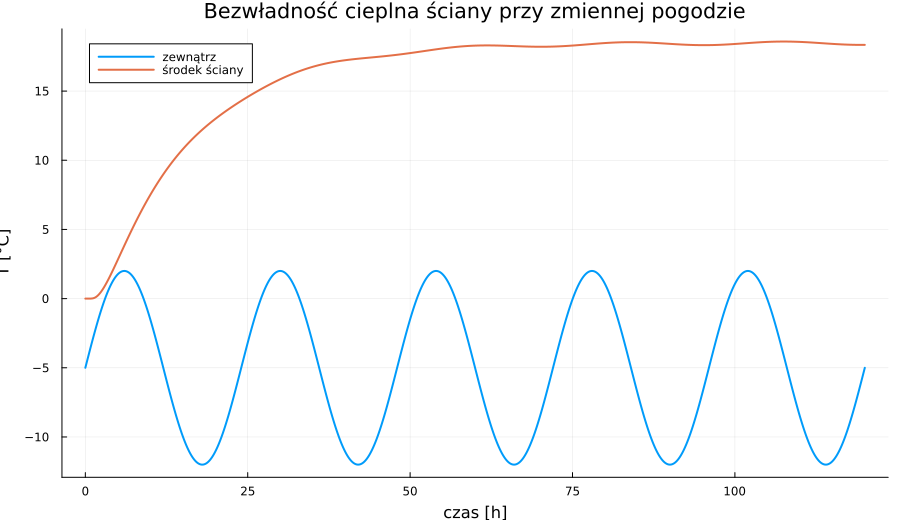

In [13]:

T_right_daily(t) = -5.0 + 7.0 * sin(2π * t / (24*3600.0))

x, k, rhoc, names = build_wall(wall_with_insulation; Nx=151)
T0 = fill(0.0, length(x))
T0[1] = Tin
T0[end] = T_right_daily(0.0)

times_daily, sol_daily = solve_wall_crank_nicolson(x, k, rhoc;
    T_initial=T0,
    T_left=T_left,
    T_right=T_right_daily,
    dt=10*60.0,
    t_end=5*24*3600.0,
    save_every=1
)

mid = round(Int, length(x)/2)
plot(times_daily ./ 3600, [T_right_daily(t) for t in times_daily], label="zewnątrz")
plot!(times_daily ./ 3600, sol_daily[:, mid], label="środek ściany")
plot!(xlabel="czas [h]", ylabel="T [°C]",
      title="Bezwładność cieplna ściany przy zmiennej pogodzie")


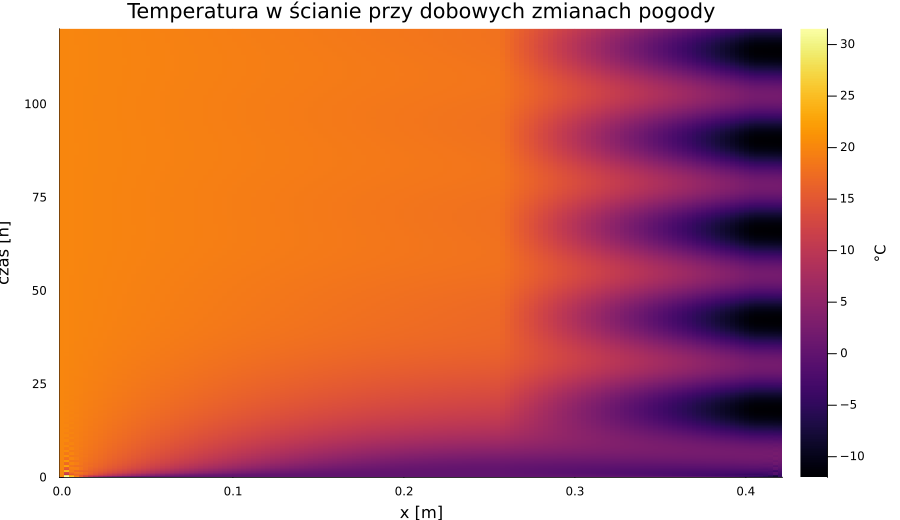

In [14]:

heatmap(x, times_daily ./ 3600, sol_daily,
        xlabel="x [m]",
        ylabel="czas [h]",
        title="Temperatura w ścianie przy dobowych zmianach pogody",
        colorbar_title="°C")



## 12. Analiza dokładności na przykładzie z rozwiązaniem analitycznym

Dla jednorodnego pręta z warunkami brzegowymi $T(0,t)=T(1,t)=0$ i warunkiem początkowym

$$
T(x,0)=\sin(\pi x)
$$

rozwiązanie dokładne ma postać:

$$
T(x,t)=e^{-\alpha \pi^2 t}\sin(\pi x).
$$

Na tym przykładzie sprawdzamy, czy wraz z zagęszczaniem siatki błąd maleje.


Nx     dx           błąd L2
41     0.025000     8.367942e-05
81     0.012500     8.542787e-05
161    0.006250     1.335261e-05
321    0.003125     1.322071e-06

Przybliżone rzędy zbieżności:
-0.03
2.68
3.34


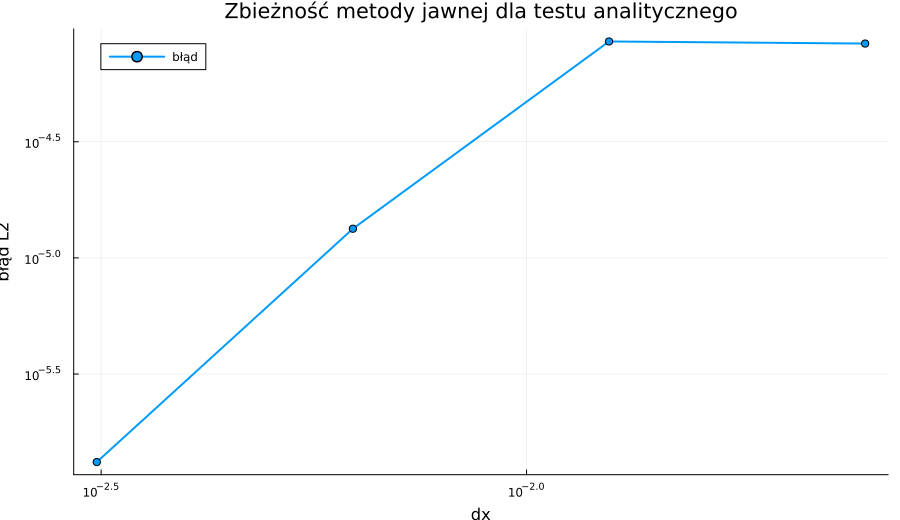

In [15]:

function exact_heat_solution(x, t, α)
    return exp(-α * π^2 * t) .* sin.(π .* x)
end

function accuracy_test_explicit(Nx_values; α=0.01, t_end=0.1)
    errors = Float64[]
    dxs = Float64[]

    for Nx in Nx_values
        layer = [Layer(name="jednorodny materiał", thickness=1.0, k=α, rho=1.0, c=1.0)]
        x, k, rhoc, names = build_wall(layer; Nx=Nx)
        dx = x[2] - x[1]
        dt = 0.4 * explicit_dt_limit(k, rhoc, dx)

        T0 = exact_heat_solution(x, 0.0, α)
        times, sol = solve_wall_explicit(x, k, rhoc;
            T_initial=T0,
            T_left=t -> 0.0,
            T_right=t -> 0.0,
            dt=dt,
            t_end=t_end,
            save_every=ceil(Int, t_end/dt)
        )

        T_num = sol[end, :]
        T_exact = exact_heat_solution(x, t_end, α)
        err = sqrt(mean((T_num .- T_exact).^2))
        push!(errors, err)
        push!(dxs, dx)
    end

    return dxs, errors
end

Nx_values = [41, 81, 161, 321]
dxs, errors = accuracy_test_explicit(Nx_values)

println("Nx     dx           błąd L2")
for (Nx, dx, err) in zip(Nx_values, dxs, errors)
    @printf("%-6d %.6f     %.6e\n", Nx, dx, err)
end

rates = [log(errors[i]/errors[i+1]) / log(dxs[i]/dxs[i+1]) for i in 1:length(errors)-1]
println("\nPrzybliżone rzędy zbieżności:")
for r in rates
    @printf("%.2f\n", r)
end

plot(dxs, errors,
     xaxis=:log,
     yaxis=:log,
     marker=:circle,
     xlabel="dx",
     ylabel="błąd L2",
     title="Zbieżność metody jawnej dla testu analitycznego",
     label="błąd")



## 13. Analiza wydajności

Porównujemy orientacyjnie czas obliczeń dla metod:

- jawnej,
- niejawnej,
- Cranka–Nicolsona.

Wniosek teoretyczny:

- metoda jawna ma bardzo tani krok, ale wymaga bardzo małego $\Delta t$,
- metody niejawne mają droższy krok, ale pozwalają na dużo większy $\Delta t$,
- dla długich symulacji metoda niejawna lub Crank–Nicolson mogą być szybsze.


In [16]:

function benchmark_methods()
    x, k, rhoc, names = build_wall(wall_with_insulation; Nx=151)
    T0 = fill(0.0, length(x))
    T0[1] = Tin
    T0[end] = Tout

    dx = x[2] - x[1]
    dt_exp = 0.8 * explicit_dt_limit(k, rhoc, dx)
    dt_imp = 10 * 60.0
    short_time = 24 * 3600.0

    println("Benchmark dla 24 h symulacji")

    t1 = @elapsed solve_wall_explicit(x, k, rhoc;
        T_initial=T0, T_left=T_left, T_right=T_right,
        dt=dt_exp, t_end=short_time, save_every=10^9)

    t2 = @elapsed solve_wall_implicit(x, k, rhoc;
        T_initial=T0, T_left=T_left, T_right=T_right,
        dt=dt_imp, t_end=short_time, save_every=10^9)

    t3 = @elapsed solve_wall_crank_nicolson(x, k, rhoc;
        T_initial=T0, T_left=T_left, T_right=T_right,
        dt=dt_imp, t_end=short_time, save_every=10^9)

    @printf("Euler jawny:       %.4f s, dt = %.2f s\n", t1, dt_exp)
    @printf("Euler niejawny:    %.4f s, dt = %.2f s\n", t2, dt_imp)
    @printf("Crank–Nicolson:    %.4f s, dt = %.2f s\n", t3, dt_imp)
end

benchmark_methods()


Benchmark dla 24 h symulacji
Euler jawny:       0.2271 s, dt = 0.78 s
Euler niejawny:    0.0009 s, dt = 600.00 s
Crank–Nicolson:    0.0008 s, dt = 600.00 s



## 14. Złożoność obliczeniowa

Niech $N$ oznacza liczbę punktów siatki.

### Metoda jawna

Jeden krok czasowy wykonuje mnożenie przez rzadki operator trójdiagonalny, więc koszt to:

$$
O(N).
$$

Problem: liczba kroków może być bardzo duża, bo $\Delta t$ musi być małe.

### Metoda niejawna i Crank–Nicolson

W każdym kroku rozwiązujemy układ liniowy:

$$
A x=b.
$$

W 1D macierz jest trójdiagonalna lub rzadka, więc koszt może być bliski $O(N)$, jeśli używamy odpowiedniego solvera. W 2D układy są większe i droższe — wtedy warto rozważyć metody iteracyjne, np. CG lub GMRES.

### Alternatywy

- metoda elementów skończonych,
- metoda objętości skończonych,
- adaptacyjny krok czasowy,
- metody iteracyjne dla dużych układów,
- rozszerzenie do modelu 2D ściany lub ogrzewania podłogowego.



## 15. Praktyczne znaczenie wyników

Z projektu można wyciągnąć kilka praktycznych wniosków:

1. **Izolacja mocno redukuje straty ciepła.** W symulacji widać spadek strumienia ciepła $q$ po dodaniu warstwy styropianu.
2. **Ściana ma bezwładność cieplną.** Temperatura w środku ściany zmienia się wolniej niż temperatura zewnętrzna.
3. **Dobór kroku czasowego jest krytyczny.** Metoda jawna może dać absurdalne wyniki, jeśli złamiemy warunek stabilności.
4. **Metody niejawne są wygodne dla długich symulacji.** Pozwalają używać większych kroków czasowych.
5. **Model można łatwo rozszerzyć.** Na przykład o warunki Robina, zmienną temperaturę pokoju, ogrzewanie podłogowe albo mostki cieplne.



## 16. Szkic pakietu Julia na GitHuba

Proponowana struktura repozytorium:

```text
ChataHeatDiffusion.jl/
├── Project.toml
├── README.md
├── src/
│   └── ChataHeatDiffusion.jl
├── test/
│   └── runtests.jl
├── examples/
│   ├── wall_insulation.jl
│   ├── cfl_failure.jl
│   └── benchmark.jl
└── docs/
```

Eksportowane metody:

- `Layer`,
- `build_wall`,
- `solve_wall_explicit`,
- `solve_wall_implicit`,
- `solve_wall_crank_nicolson`,
- `steady_flux_from_layers`,
- `heat_flux_left`.

W paczce należy dodać docstringi do każdej eksportowanej metody.



## 16.1 Przykład docstringa do pakietu

Poniższy fragment można przenieść do pliku `src/ChataHeatDiffusion.jl` nad definicję funkcji:

```julia
"""
    solve_wall_explicit(x, k, rhoc; T_initial, T_left, T_right, dt, t_end, save_every=1)

Rozwiązuje jednowymiarowe równanie przewodnictwa ciepła w ścianie metodą jawną Eulera.

# Argumenty
- `x`: wektor punktów siatki.
- `k`: przewodność cieplna w punktach siatki.
- `rhoc`: pojemność cieplna objętościowa `rho*c`.
- `T_initial`: temperatura początkowa.
- `T_left`: funkcja temperatury na lewym brzegu.
- `T_right`: funkcja temperatury na prawym brzegu.
- `dt`: krok czasowy.
- `t_end`: czas końcowy symulacji.
- `save_every`: co ile kroków zapisywać rozwiązanie.

# Zwraca
- `times`: zapisane chwile czasu,
- `sol`: macierz temperatur, gdzie wiersze odpowiadają czasom, a kolumny punktom siatki.
"""
function solve_wall_explicit(...)
    # implementacja
end
```



## 17. Pomysły na slajdy z prezentacji

1. **Motywacja:** ile ciepła ucieka z domu zimą?
2. **Model fizyczny:** równanie przewodnictwa ciepła i warstwy ściany.
3. **Metody numeryczne:** Euler jawny, Euler niejawny, Crank–Nicolson.
4. **Co może pójść źle:** złamany warunek CFL.
5. **Wyniki:** profile temperatury, heatmapa w czasie.
6. **Porównanie materiałów:** bez izolacji kontra styropian.
7. **Dokładność:** test z rozwiązaniem analitycznym.
8. **Wydajność:** benchmark metod.
9. **Znaczenie praktyczne:** spadek strat energii.
10. **Pakiet Julia:** struktura repozytorium, eksportowane funkcje, dokumentacja.
